# Query Recall vs. Attribute Count and Distance Evaluation

This notebook evaluates the performance (**Accuracy/Recall@5/10/20**) of four different models on the test split of the Rec2Vec dataset as a function of:
1. **Number of Attributes:** The total count of all features specified in the query (sum of positive, negative, common, and neither attributes).
2. **Query Distance:** The number of differentiating attributes (sum of unique positive and unique negative features, representing the existing `query_distance` field in the dataset).

### Methodology
1. **Dataset Split:** We load the raw dataset and replicate the exact query-level `80/10/10` train/val/test split used during training, isolating the 10% test queries.
2. **Corpus Construction:** The retrieval corpus is built from all unique positive products, hard negative products, and easy negative products belonging to the test split, mirroring the exact evaluation environment of `train_fork_val.py`.
3. **Metrics:** For each model, we encode the corpus and query texts, batch-compute the cosine similarity rankings, and measure Accuracy and Recall at K=5, 10, and 20. We group and plot performance against both query attribute count and query distance.

In [1]:
import os
# Set CUDA device to 5 as requested by the user
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import json
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

/local-scratch1/data/mt/Rec2Vec/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Load Dataset

In [2]:
DATASET_PATH = "dataset/feature-distance-dataset_gemini-2.5-flash_1000000_fixed_distance.jsonl"

print(f"Loading dataset from {DATASET_PATH}...")
entries = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            entries.append(json.loads(line))
print(f"Loaded {len(entries):,} total entries.")

Loading dataset from dataset/feature-distance-dataset_gemini-2.5-flash_1000000_fixed_distance.jsonl...
Loaded 171,762 total entries.


## 2. Query-Level Train/Val/Test Split

We replicate the exact query splitting process from the training script to evaluate only on the test split.

In [3]:
# Replicate the query-level train/val/test split using random state 42
unique_queries = pd.Series([e["nl_query"] for e in entries]).drop_duplicates().tolist()
print(f"Total unique queries in dataset: {len(unique_queries):,}")

train_queries, temp_queries = train_test_split(unique_queries, test_size=0.2, random_state=42)
eval_queries, test_queries = train_test_split(temp_queries, test_size=0.5, random_state=42)
test_queries_set = set(test_queries)

print(f"Split sizes: {len(train_queries):,} train, {len(eval_queries):,} val, {len(test_queries):,} test unique queries.")

# Filter to keep only test split entries
test_entries = [e for e in entries if e["nl_query"] in test_queries_set]
print(f"Filtered test split entries: {len(test_entries):,}")

Total unique queries in dataset: 171,762
Split sizes: 137,409 train, 17,176 val, 17,177 test unique queries.
Filtered test split entries: 17,177


## 3. Construct Corpus and Query Mappings

We build the retrieval corpus out of all unique positive, hard negative, and easy negative products present in the test split. We compute the total number of attributes (features) and extract the existing `query_distance` for each test example.

In [4]:
# Gather all unique product texts present in the test set
corpus_texts = list(set(
    [e["positive_product"]["product_text"] for e in test_entries] +
    [e["hard_neg_product"]["product_text"] for e in test_entries] +
    [e["easy_neg_product"]["product_text"] for e in test_entries]
))
print(f"Retrieval corpus size: {len(corpus_texts):,} unique product texts.")
corpus_to_idx = {txt: i for i, txt in enumerate(corpus_texts)}

# Map each unique test query to its ground-truth positive product index
query_to_positives = {}
query_to_num_attributes = {}
query_to_distance = {}

for e in test_entries:
    q = e["nl_query"]
    pos_txt = e["positive_product"]["product_text"]
    
    if q not in query_to_positives:
        query_to_positives[q] = set()
    query_to_positives[q].add(corpus_to_idx[pos_txt])
    
    # 1. Total Number of attributes is the sum of all selected feature categories
    num_attrs = (
        len(e["selected_pos_features"]) +
        len(e["selected_neg_features"]) +
        len(e["selected_common_features"]) +
        len(e["selected_neither_features"])
    )
    query_to_num_attributes[q] = num_attrs
    
    # 2. Query distance (existing differentiation field, which equals len(pos_features) + len(neg_features))
    query_to_distance[q] = e["query_distance"]

unique_test_queries = list(query_to_positives.keys())
relevant_corpus_ids = [list(query_to_positives[q]) for q in unique_test_queries]
query_attr_counts = [query_to_num_attributes[q] for q in unique_test_queries]
query_distances = [query_to_distance[q] for q in unique_test_queries]

print(f"Evaluation queries count: {len(unique_test_queries):,}")

Retrieval corpus size: 41,041 unique product texts.
Evaluation queries count: 17,177


## 4. Load Models

We load the baseline pre-trained model and four fine-tuned checkpoints: the sweep weights (`_best`/`_keep`) for Triplet / Classic MSE / Ours MSE, plus the 2026-08-04 InfoNCE run.

In [6]:
MODEL_PATHS = {
    "Pre-trained (baseline)": "all-mpnet-base-v2",
    "Fine-tuned (Triplet)": "models/schachaf/baseline-triplet_keep",
    "Fine-tuned (Classic MSE)": "models/schachaf/classic-mse_best",
    "Fine-tuned (Ours MSE)": "models/schachaf/ours-mse_best",
    # 2026-08-04 run: train_fork.py --training-style baseline-infonce (base: microsoft/mpnet-base)
    "Fine-tuned (InfoNCE)": "models/infonce-all-mpnet-base-v2/final",
}

models = {}
for name, path in MODEL_PATHS.items():
    print(f"Loading {name} from {path}...")
    models[name] = SentenceTransformer(path, device=DEVICE)
    print(f"  Embedding dimension: {models[name].get_sentence_embedding_dimension()}")

print(f"\nAll {len(models)} models loaded successfully.")

Loading Pre-trained (baseline) from all-mpnet-base-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6431.74it/s]
/tmp/ipykernel_1240136/2435735646.py:14: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"  Embedding dimension: {models[name].get_sentence_embedding_dimension()}")


  Embedding dimension: 768
Loading Fine-tuned (Triplet) from models/schachaf/baseline-triplet_keep...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6676.90it/s]
/tmp/ipykernel_1240136/2435735646.py:14: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"  Embedding dimension: {models[name].get_sentence_embedding_dimension()}")


  Embedding dimension: 768
Loading Fine-tuned (Classic MSE) from models/schachaf/classic-mse_best...


...

  Embedding dimension: 768
Loading Fine-tuned (Ours MSE) from models/schachaf/ours-mse_best...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6125.90it/s]

  Embedding dimension: 768
Loading Fine-tuned (InfoNCE) from models/infonce-all-mpnet-base-v2/final...



/tmp/ipykernel_1240136/2435735646.py:14: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"  Embedding dimension: {models[name].get_sentence_embedding_dimension()}")
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6092.72it/s]
/tmp/ipykernel_1240136/2435735646.py:14: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"  Embedding dimension: {models[name].get_sentence_embedding_dimension()}")


  Embedding dimension: 768

All 5 models loaded successfully.


## 5. Evaluate Retrieval Ranks and Metrics

We batch-encode texts to optimize memory usage, compute cosine similarity, and determine accuracy and recall at K=5, 10, and 20.

In [7]:
def encode_texts(model, texts, batch_size=256):
    embeddings = model.encode(
        texts,
        convert_to_tensor=True,
        show_progress_bar=True,
        batch_size=batch_size,
    )
    # L2 normalize so dot product equals cosine similarity
    embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
    return embeddings.cpu().numpy()

all_model_results = []

for name, model in models.items():
    print(f"\nEncoding corpus for {name}...")
    corpus_embeddings = encode_texts(model, corpus_texts)
    
    print(f"Encoding queries for {name}...")
    query_embeddings = encode_texts(model, unique_test_queries)
    
    print(f"Computing retrieval ranks and metrics for {name}...")
    batch_size = 256
    num_queries = len(query_embeddings)
    
    accuracies = {5: [], 10: [], 20: []}
    recalls = {5: [], 10: [], 20: []}
    
    for i in tqdm(range(0, num_queries, batch_size)):
        q_batch = query_embeddings[i:i+batch_size]
        scores = q_batch @ corpus_embeddings.T # [batch_size, corpus_size]
        
        for idx in range(len(q_batch)):
            q_idx = i + idx
            positives = relevant_corpus_ids[q_idx]
            q_scores = scores[idx]
            
            # Sort corpus indices by score descending
            ranked_indices = np.argsort(-q_scores)
            positives_set = set(positives)
            
            for k in [5, 10, 20]:
                top_k_retrieved = set(ranked_indices[:k])
                hits_in_k = positives_set.intersection(top_k_retrieved)
                
                # Accuracy@K (Hit@K) is 1.0 if at least one positive is retrieved, else 0.0
                acc = 1.0 if len(hits_in_k) > 0 else 0.0
                # Recall@K is percentage of relevant positives retrieved
                rec = len(hits_in_k) / len(positives_set)
                
                accuracies[k].append(acc)
                recalls[k].append(rec)
                
    df = pd.DataFrame({
        "num_attributes": query_attr_counts,
        "query_distance": query_distances,
        "acc@5": accuracies[5],
        "acc@10": accuracies[10],
        "acc@20": accuracies[20],
        "recall@5": recalls[5],
        "recall@10": recalls[10],
        "recall@20": recalls[20],
    })
    df["model"] = name
    all_model_results.append(df)

results_df = pd.concat(all_model_results, ignore_index=True)
print("Finished computing evaluation metrics for all models.")


Encoding corpus for Pre-trained (baseline)...


Batches: 100%|██████████| 161/161 [02:40<00:00,  1.00it/s]


Encoding queries for Pre-trained (baseline)...


Batches: 100%|██████████| 68/68 [00:16<00:00,  4.18it/s]


Computing retrieval ranks and metrics for Pre-trained (baseline)...


...

Encoding queries for Fine-tuned (InfoNCE)...


Batches: 100%|██████████| 68/68 [00:20<00:00,  3.32it/s]


Computing retrieval ranks and metrics for Fine-tuned (InfoNCE)...


100%|██████████| 68/68 [00:20<00:00,  3.26it/s]

Finished computing evaluation metrics for all models.


## 6. Plot Results

We group the test set performance by both **query attribute count** (total features) and **query distance** (differentiating positive and negative unique features), producing side-by-side recall plots.

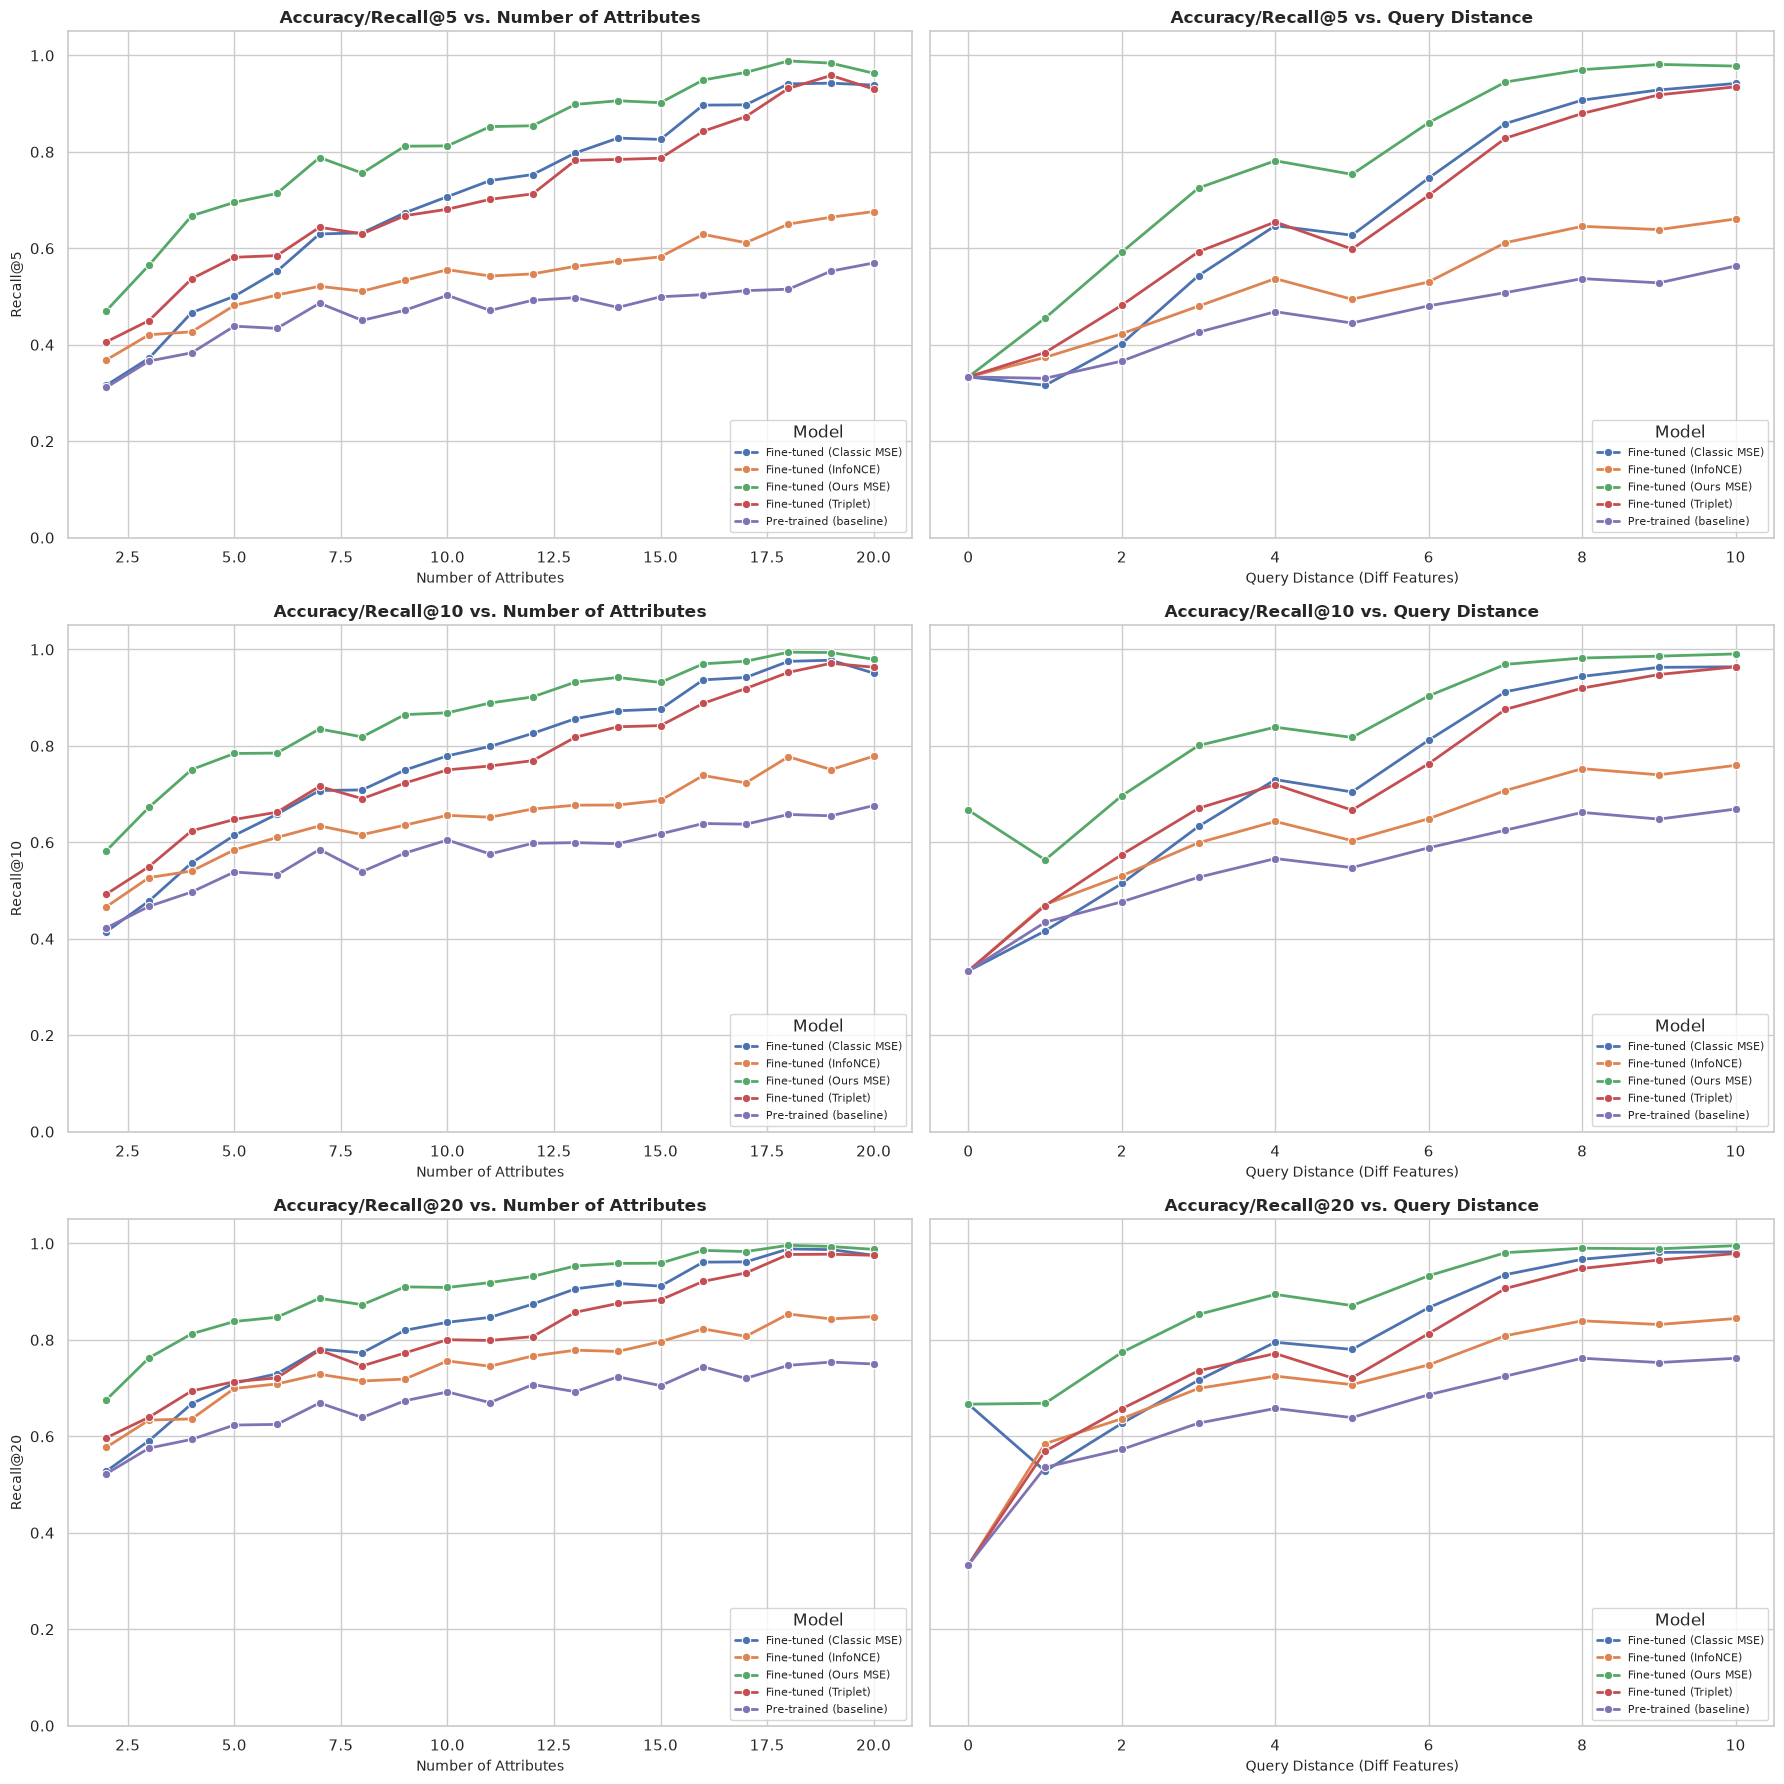

In [8]:
# Group by model and attributes/distance
grouped_attrs = results_df.groupby(["model", "num_attributes"])[["acc@5", "acc@10", "acc@20"]].mean().reset_index()
grouped_dist = results_df.groupby(["model", "query_distance"])[["acc@5", "acc@10", "acc@20"]].mean().reset_index()

# Set up side-by-side subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 18), sharey=True)
metrics_k = [5, 10, 20]

for idx, k in enumerate(metrics_k):
    # Left Column: Accuracy/Recall vs. Number of Attributes
    ax_left = axes[idx, 0]
    sns.lineplot(
        data=grouped_attrs,
        x="num_attributes",
        y=f"acc@{k}",
        hue="model",
        marker="o",
        linewidth=2,
        ax=ax_left
    )
    ax_left.set_title(f"Accuracy/Recall@{k} vs. Number of Attributes", fontsize=12, fontweight="bold")
    ax_left.set_ylabel(f"Recall@{k}", fontsize=10)
    ax_left.set_xlabel("Number of Attributes", fontsize=10)
    ax_left.set_ylim(0.0, 1.05)
    ax_left.legend(title="Model", loc="lower right", fontsize=8)
    
    # Right Column: Accuracy/Recall vs. Query Distance
    ax_right = axes[idx, 1]
    sns.lineplot(
        data=grouped_dist,
        x="query_distance",
        y=f"acc@{k}",
        hue="model",
        marker="o",
        linewidth=2,
        ax=ax_right
    )
    ax_right.set_title(f"Accuracy/Recall@{k} vs. Query Distance", fontsize=12, fontweight="bold")
    ax_right.set_ylabel(f"Recall@{k}", fontsize=10)
    ax_right.set_xlabel("Query Distance (Diff Features)", fontsize=10)
    ax_right.set_ylim(0.0, 1.05)
    ax_right.legend(title="Model", loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Model Performance Overview

Averaged over all query lengths, here are the final performance metrics.

In [9]:
print("Global Mean Accuracy/Recall by Model:")
summary = results_df.groupby("model")[["acc@5", "acc@10", "acc@20"]].mean().reset_index()
display(summary)

Global Mean Accuracy/Recall by Model:


,model,acc@5,acc@10,acc@20
0,Fine-tuned (Classic MSE),0.675205,0.747104,0.809571
1,Fine-tuned (InfoNCE),0.530186,0.638004,0.735577
2,Fine-tuned (Ours MSE),0.796938,0.851022,0.892938
3,Fine-tuned (Triplet),0.679397,0.741166,0.792863
4,Pre-trained (baseline),0.460383,0.568784,0.665658
